<center><h1><b>LABORATORY 6</b></h1></center>

---

In [4]:
library(coda)
library(rjags)
library(rstan)
library(bnlearn, lib.loc = "~/R/x86_64-pc-linux-gnu-library/4.3")  # installato in libreria personale

---

# Exercise 1: Quadratic Bayesian regression using Stan
The following n = 9 data sample

| X  |  Y        |  $\sigma_i$  |
|----|-----------|-----------|
| 2  | 105.5203  | 15.40459  |
| 3  | 227.4457  | 36.05480  |
| 4  | 405.6937  | 51.84040  |
| 5  | 661.2858  | 94.66744  |
| 6  | 886.1422  | 123.79828 |
| 7  | 1189.6514 | 216.99935 |
| 8  | 1631.8262 | 173.83507 |
| 9  | 1951.8381 | 318.46511 |
| 10 | 2528.5246 | 427.27788 |

is believed to follow
 
$ Y = \beta_0 + \beta_1 \cdot X + \beta_2 \cdot X^2 $

#### 1. Let the prior distributions for $\beta$ parameters be,
- $\beta_0$ normal distribution centered at 5 with a standard deviation of 1.
- $\beta_1$ uniform distribution between -1 and 1.
- $\beta_2$ normal distribution centered at 30 with a standard deviation of 15.

Build a Stan model and run a MCMC to obtain the posterior distribution of the $\beta$ parameters using also the $\sigma_i$ uncertainty for each measurement.

Inference for Stan model: anon_model.
2 chains, each with iter=4000; warmup=500; thin=1; 
post-warmup draws per chain=3500, total post-warmup draws=7000.

       mean se_mean   sd  2.5%   25%   50%   75% 97.5% n_eff Rhat
beta0  5.01    0.01 1.00  3.05  4.34  5.01  5.70  6.91  5575    1
beta1  0.00    0.01 0.58 -0.96 -0.50  0.00  0.50  0.95  7728    1
beta2 25.01    0.02 1.21 22.61 24.19 25.01 25.85 27.39  5729    1

Samples were drawn using NUTS(diag_e) at Thu Jun  5 18:30:37 2025.
For each parameter, n_eff is a crude measure of effective sample size,
and Rhat is the potential scale reduction factor on split chains (at 
convergence, Rhat=1).


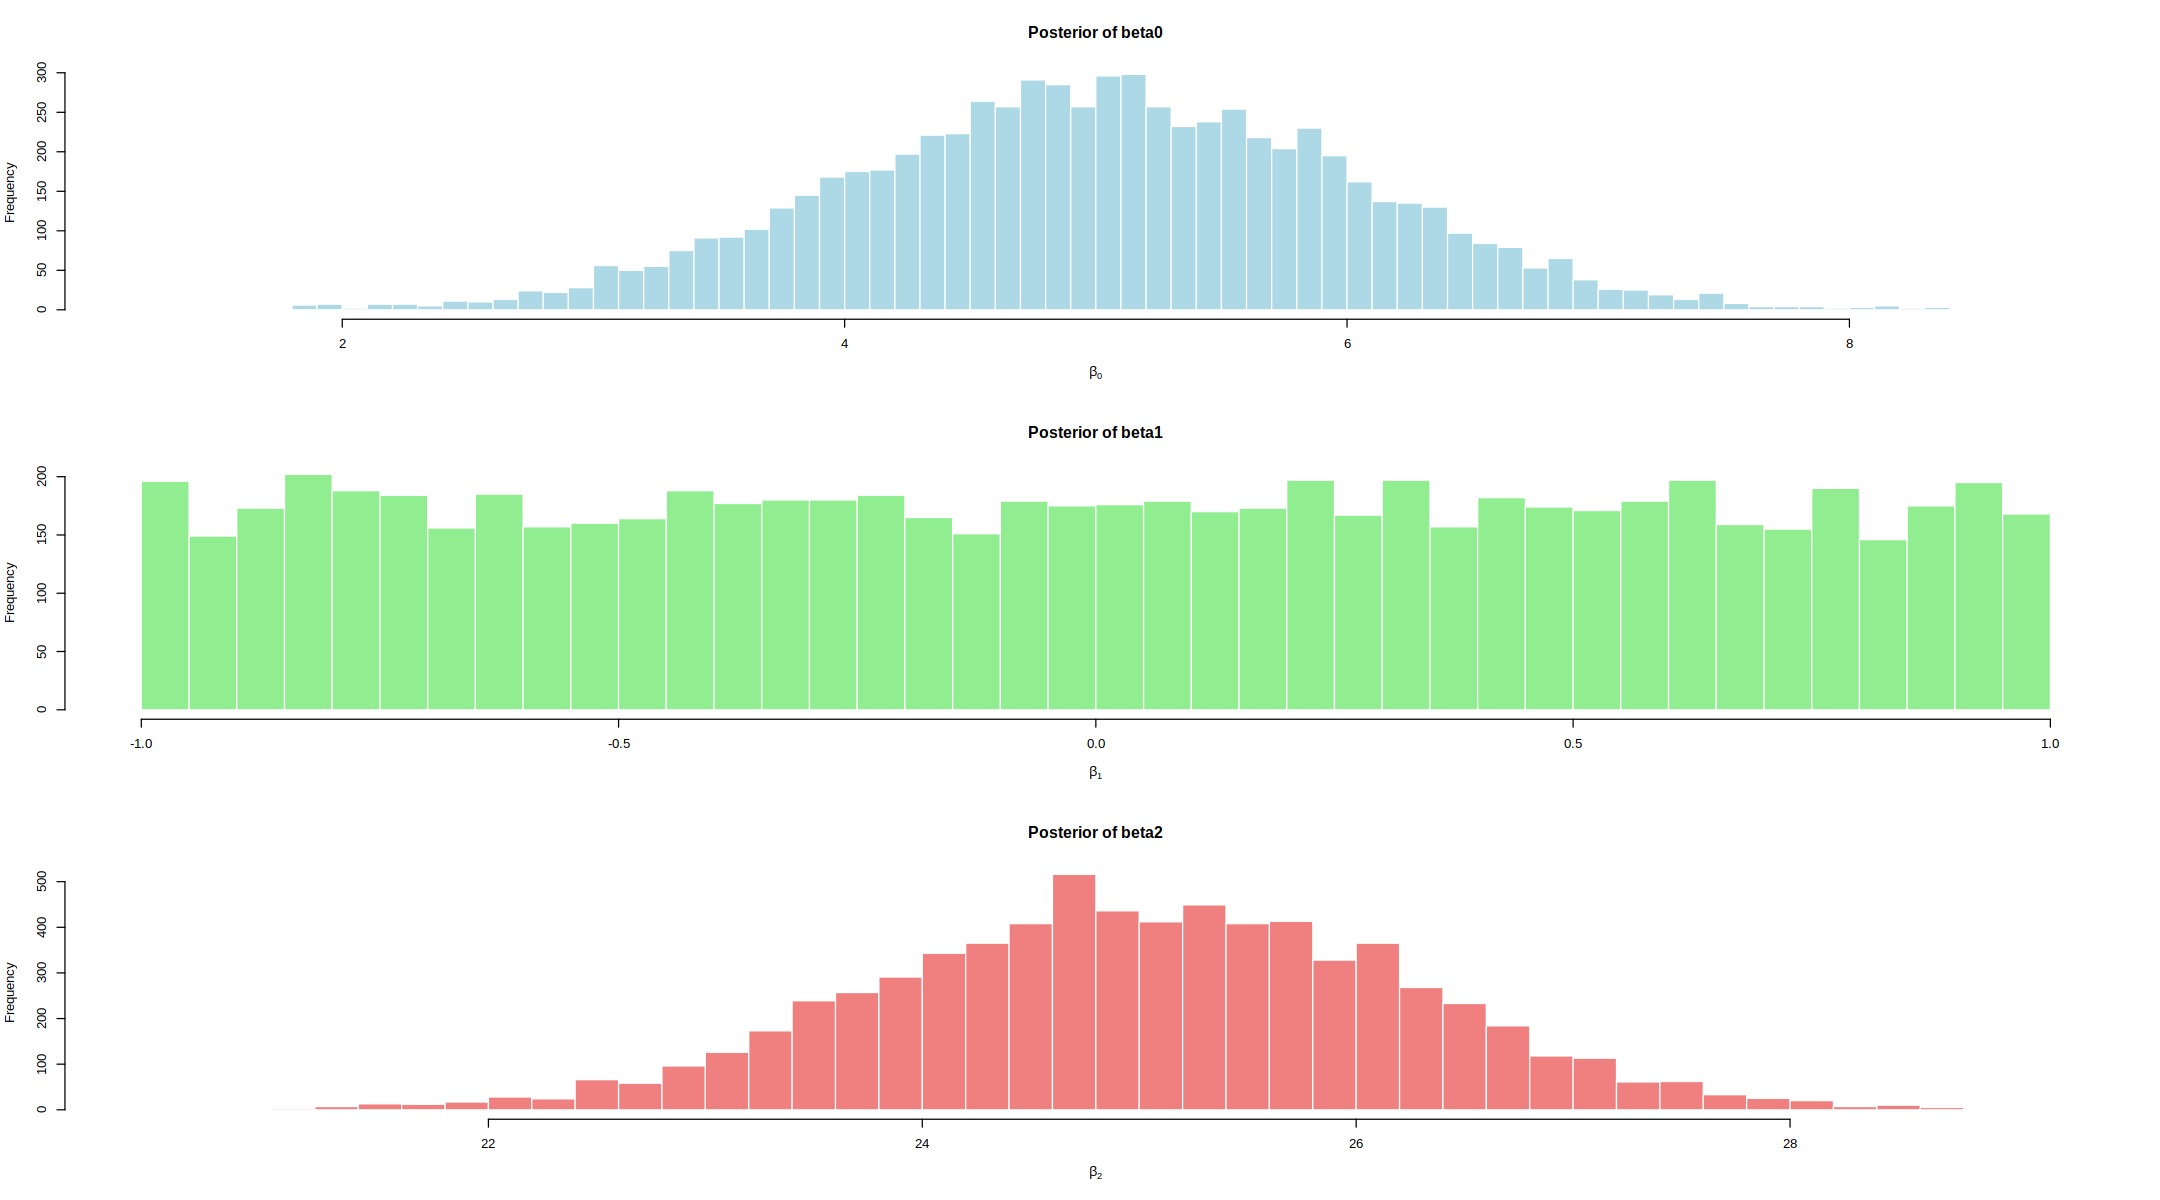

In [12]:
# Step 1: DATA
x <- 2:10
y <- c(105.5203, 227.4457, 405.6937, 661.2858, 886.1422, 1189.6514, 1631.8262, 1951.8381, 2528.5246)
sigma <- c(15.40459, 36.05480, 51.84040, 94.66744, 123.79828, 216.99935, 173.83507, 318.46511, 427.27788)
N <- length(x)

# Step 2: DATA LIST FOR STAN
stan_data <- list(N = N, x = x, y = y, sigma = sigma)

# Step 3: MODEL for stan
stan_code <- "
data {
  int<lower=1> N;           // number of data points
  vector[N] x;              // predictor (vector of length N)
  vector[N] y;              // response (vector of length N)
  vector[N] sigma;          // known std deviation of each observation (vector of length N)
}
parameters {                       // here we have the unknown quantities we want to estimate
  real beta0;                      // intercept
  real<lower=-1, upper=1> beta1;   // linear term
  real beta2;                      // quadratic term
}
model {
  // Priors
  beta0 ~ normal(5, 1);
  beta2 ~ normal(30, 15);
  beta1 ~ uniform(-1, 1);
  // Likelihood
  for (i in 1:N) {
    y[i] ~ normal(beta0 + beta1 * x[i] + beta2 * square(x[i]), sigma[i]);
  }
}"
model <- stan_model(model_code = stan_code)   # compiling the model

# Step 4: RUN SAMPLING
fit <- sampling(
  model,
  data = stan_data,
  iter = 4000,
  warmup = 500,
  chains = 2,
  refresh = 0  # <-- suppress progress output
)

#Step 5: Print SUMMARY of posterior
print(fit, pars = c("beta0", "beta1", "beta2"))       # Print posterior summaries

# Step 6: Plot SUMMARY of posterior
posterior <- extract(fit)             # Extract posterior samples
options(repr.plot.width = 18, repr.plot.height = 10)
par(mfrow = c(3, 1))  # 3 row, 1 columns       # Plot histograms of posterior samples for each parameter
hist(posterior$beta0, breaks = 60, main = "Posterior of beta0",
     xlab = expression(beta[0]), col = "lightblue", border = "white")
hist(posterior$beta1, breaks = 60, main = "Posterior of beta1",
     xlab = expression(beta[1]), col = "lightgreen", border = "white")
hist(posterior$beta2, breaks = 60, main = "Posterior of beta2",
     xlab = expression(beta[2]), col = "lightcoral", border = "white")
par(mfrow = c(1, 1))  # Reset layout


#### 2. Compute the 95% credibility interval for each β parameter.

In [14]:
# Extract posterior samples
posterior_samples <- extract(fit)

# Compute 95% credible intervals
ci_beta0 <- quantile(posterior_samples$beta0, probs = c(0.025, 0.975))
ci_beta1 <- quantile(posterior_samples$beta1, probs = c(0.025, 0.975))
ci_beta2 <- quantile(posterior_samples$beta2, probs = c(0.025, 0.975))

# Print results with explanation
cat("95% Bayesian credible intervals for each beta parameter:\n\n")
cat(sprintf("β₀: [%.3f, %.3f]\n", ci_beta0[1], ci_beta0[2]))
cat(sprintf("β₁: [%.3f, %.3f]\n", ci_beta1[1], ci_beta1[2]))
cat(sprintf("β₂: [%.3f, %.3f]\n", ci_beta2[1], ci_beta2[2]))

95% Bayesian credible intervals for each beta parameter:

β₀: [3.048, 6.912]
β₁: [-0.956, 0.948]
β₂: [22.606, 27.386]


#### 3. Draw the fitted quadratic funtion (using the mean values of the β parameters from MCMC) together with data points and their uncertainties.

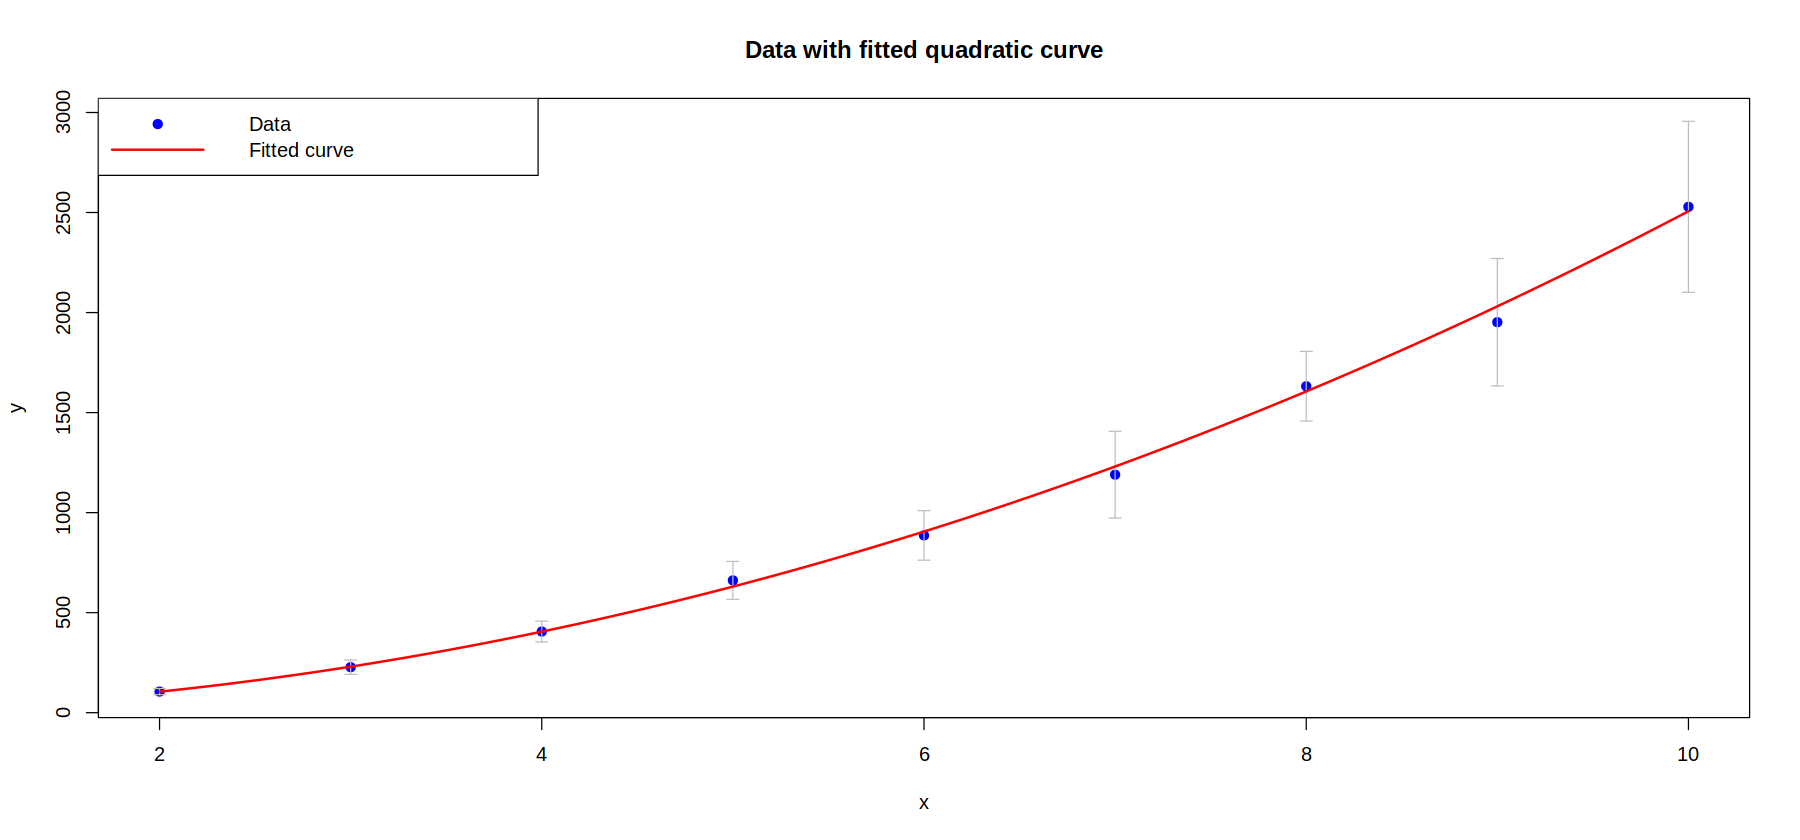

In [16]:
# Posterior means of beta parameters
beta0_mean <- mean(posterior_samples$beta0)
beta1_mean <- mean(posterior_samples$beta1)
beta2_mean <- mean(posterior_samples$beta2)

# Evaluate the fitted curve at a sequence of x values
x_seq <- seq(min(x), max(x), length.out = 100)
y_fit <- beta0_mean + beta1_mean * x_seq + beta2_mean * x_seq^2

# Plot data points with error bars
options(repr.plot.width = 15, repr.plot.height = 7)
plot(x, y, ylim = range(c(y - sigma, y + sigma, y_fit)),
     xlab = "x", ylab = "y", pch = 19, col = "blue", main = "Data with fitted quadratic curve")
# Add error bars
arrows(x, y - sigma, x, y + sigma, angle = 90, code = 3, length = 0.05, col = "gray")
# Add fitted curve
lines(x_seq, y_fit, col = "red", lwd = 2)
# Add legend
legend("topleft", legend = c("Data", "Fitted curve"),
       col = c("blue", "red"), pch = c(19, NA), lty = c(NA, 1), lwd = c(NA, 2))

---

# Exercise 2 - study on water quality of streams

A study on water quality of streams, a high level of bacter X was defined as a level greater than 100 per 100 ml of stream water. n = 115 samples were taken from streams having a high environmental
impact on pandas. Out of these, y = 10 had a high bacter X level.

#### 1. Letting p be the probability that a sample of water taken from the stream has a high bacter X level:
(a) Find the frequentist estimator for p.\
(b) Using a Beta(1, 11) prior for p, calculate and posterior distribution $P(p | y)$.\
(c) Find the bayesian estimator for p, the posterior mean and variance, and a 95% credible interval.\
(d) Test the hypothesis $H_0: p = 0.1$ versus $H_1: p \neq 0.1$ at 5% level of significance with both the frequentist and bayesian approach.

In [5]:
n <- 115
y <- 10

In [6]:
# point A:
p_hat <- y / n
p_hat

[1] 0.08695652

Using the conjugate prior $Beta(α=1,β=11)$, and data $y=10$, $n=115$, the posterior is:
$$p∣y∼Beta(1+y,11+n−y)=Beta(11,116)$$

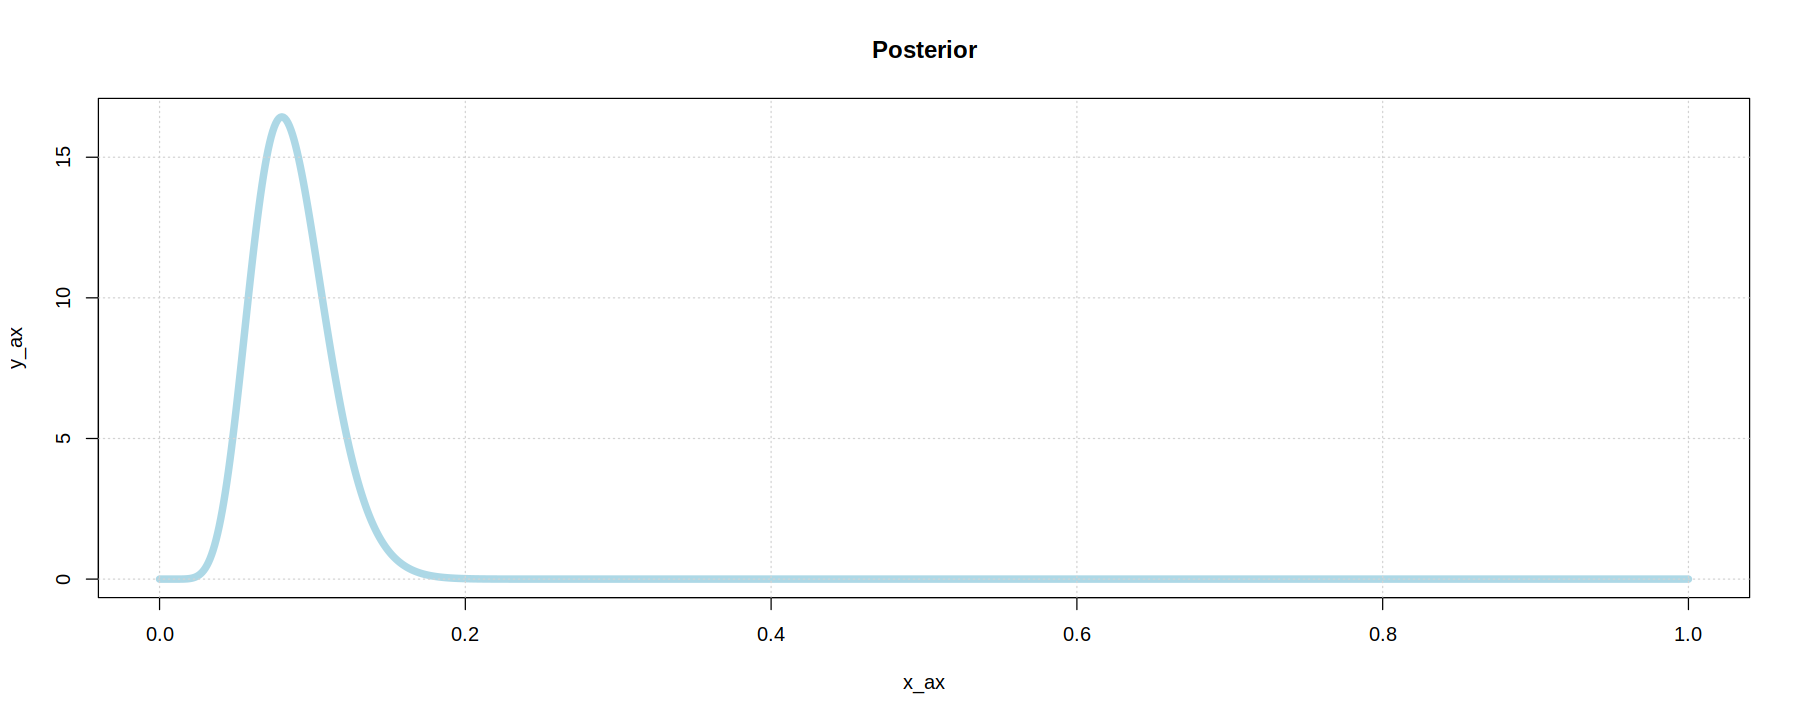

In [15]:
# point B:
alpha_prior <- 1
beta_prior <- 11

alpha_post <- alpha_prior + y
beta_post <- beta_prior + (n - y)

x_ax <- seq(0,1, 0.001)
y_ax <- dbeta(x_ax, alpha_post, beta_post)
options(repr.plot.width = 15, repr.plot.height = 6)
plot(x_ax, y_ax, type = "l", lwd = 6, col = "lightblue", main = "Posterior")
grid()  # aggiunge griglia

Posterior mean: $\text{E}[p \mid y] = \frac{\alpha_{\text{post}}}{\alpha_{\text{post}} + \beta_{\text{post}}} = \frac{11}{11 + 116}$

Posterior variance: $ \text{Var}[p \mid y] = \frac{\alpha_{\text{post}} \cdot \beta_{\text{post}}}{(\alpha_{\text{post}} + \beta_{\text{post}})^2 (\alpha_{\text{post}} + \beta_{\text{post}} + 1)}$

95% credible interval: $\text{CI}_{0.95} = \text{Quantiles of } \text{Beta}(11, 116) $


In [19]:
# point C:
# Posterior mean
post_mean <- alpha_post / (alpha_post + beta_post)
# Posterior variance
post_var <- (alpha_post * beta_post) / ((alpha_post + beta_post)^2 * (alpha_post + beta_post + 1))
# 95% credible interval
cred_int <- qbeta(c(0.025, 0.975), alpha_post, beta_post)

cat('posterior mean:', post_mean, '\n')
cat('posterior var :', post_var, '\n')
cat('posterior interval:', cred_int, '\n')

posterior mean: 0.08661417 
posterior var : 0.0006180637 
posterior interval: 0.04438876 0.1411131 


In [24]:
# point D:

# frequentis:
binom.test(y, n, p = 0.1, alternative = "two.sided")


# bayesian:
prob_near_0.1 <- pbeta(0.105, alpha_post, beta_post) - pbeta(0.095, alpha_post, beta_post)
prob_near_0.1


	Exact binomial test

data:  y and n
number of successes = 10, number of trials = 115, p-value = 0.7566
alternative hypothesis: true probability of success is not equal to 0.1
95 percent confidence interval:
 0.04248918 0.15410523
sample estimates:
probability of success 
            0.08695652 


[1] 0.1220263

#### 2. A new measurement, performed one month later on n = 165 water samples, gives y = 9 high bacter X level:
(e) Find the frequentist estimator for p.\
(f) Find a bayesian estimator for p, assuming both a Beta(1, 10) prior for p, and assuming the posterior probability of the older measurement as the prior for the new one.\
(g) Find the bayesian estimator for p, the posterior mean and variance, and a 95% credible interval.\
(h) Test the hypothesis $H_0: p = 0.1$ versus $H_1: p \neq 0.1$ at 5% level of significance with both the frequentist and bayesian approach.

In [26]:
# Dati della nuova misurazione
n2 <- 165
y2 <- 9

In [28]:
# point E:
p_freq <- y2 / n2

cat("Frequentist estimate of p:", round(p_freq, 4), "\n\n")

Frequentist estimate of p: 0.0545 



Posterior with Beta(1,10):                  Beta( 10 , 166 )
Posterior with previous posterior as prior: Beta( 20 , 272 )



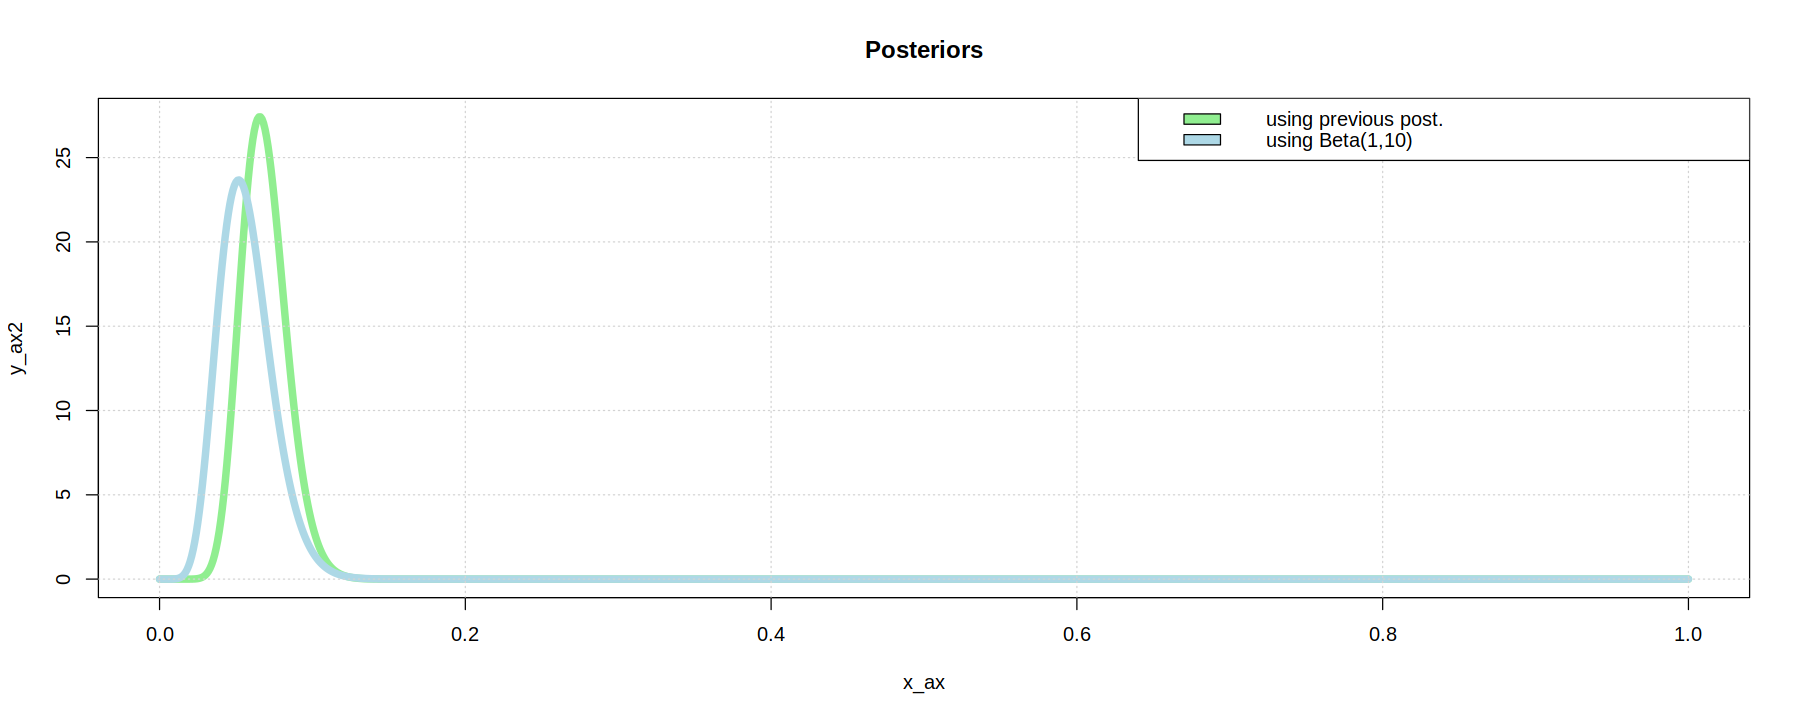

In [41]:
# point F:
a_prior1 <- 1
b_prior1 <- 10
a_prior1 <- 1
b_prior1 <- 10
a_post1 <- a_prior1 + y2
b_post1 <- b_prior1 + n2 - y2
cat("Posterior with Beta(1,10):                  Beta(", a_post1, ",", b_post1, ")\n")

a_prior2 <- 11
b_prior2 <- 116
a_post2 <- a_prior2 + y2
b_post2 <- b_prior2 + n2 - y2
cat("Posterior with previous posterior as prior: Beta(", a_post2, ",", b_post2, ")\n\n")

# plot:
x_ax <- seq(0,1, 0.001)
y_ax1 <- dbeta(x_ax, a_post1, b_post1)
y_ax2 <- dbeta(x_ax, a_post2, b_post2)
options(repr.plot.width = 15, repr.plot.height = 6)
plot(x_ax, y_ax2, type = "l", lwd = 6, col = "lightgreen", main = "Posteriors")
lines(x_ax, y_ax1, type = "l", lwd = 6, col = "lightblue")
grid()  # aggiunge griglia
legend("topright",  legend = c("using previous post.", "using Beta(1,10)"), 
       fill = c( "lightgreen", "lightblue" ))

In [43]:
# point G:
mean_post1 <- a_post1 / (a_post1 + b_post1)
var_post1 <- (a_post1 * b_post1) / ((a_post1 + b_post1)^2 * (a_post1 + b_post1 + 1))
ci_post1 <- qbeta(c(0.025, 0.975), a_post1, b_post1)

cat("Posterior with Beta(1,10):\n")
cat("  Mean:", round(mean_post1, 4), "\n")
cat("  Variance:", round(var_post1, 6), "\n")
cat("  95% Credible Interval:", paste0("[", round(ci_post1[1], 4), ", ", round(ci_post1[2], 4), "]"), "\n\n")

mean_post2 <- a_post2 / (a_post2 + b_post2)
var_post2 <- (a_post2 * b_post2) / ((a_post2 + b_post2)^2 * (a_post2 + b_post2 + 1))
ci_post2 <- qbeta(c(0.025, 0.975), a_post2, b_post2)

cat("Posterior with previous posterior as prior:\n")
cat("  Mean:", round(mean_post2, 4), "\n")
cat("  Variance:", round(var_post2, 6), "\n")
cat("  95% Credible Interval:", paste0("[", round(ci_post2[1], 4), ", ", round(ci_post2[2], 4), "]"), "\n\n")

Posterior with Beta(1,10):
  Mean: 0.0568 
  Variance: 0.000303 
  95% Credible Interval: [0.0277, 0.0954] 

Posterior with previous posterior as prior:
  Mean: 0.0685 
  Variance: 0.000218 
  95% Credible Interval: [0.0425, 0.1001] 



In [45]:
# point H:
p0 <- 0.1
se <- sqrt(p0 * (1 - p0) / n2)
z <- (p_freq - p0) / se
p_value <- 2 * pnorm(-abs(z))

cat("Frequentist test:\n")
cat("  z =", round(z, 4), "\n")
cat("  p-value =", round(p_value, 4), "\n")
if (p_value < 0.05) {
  cat("  Result: Reject H0 at 5% significance level.\n\n")
} else {
  cat("  Result: Fail to reject H0 at 5% significance level.\n\n")
}

# (h.ii) Bayesian test (95% credible interval doesn't contain 0.1?)
if (p0 < ci_post1[1] || p0 > ci_post1[2]) {
  cat("Bayesian test:\n  Result: Reject H0 (0.1 outside 95% credible interval).\n")
} else {
  cat("Bayesian test:\n  Result: Fail to reject H0 (0.1 inside 95% credible interval).\n")
}

Frequentist test:
  z = -1.9462 
  p-value = 0.0516 
  Result: Fail to reject H0 at 5% significance level.

Bayesian test:
  Result: Reject H0 (0.1 outside 95% credible interval).


---